In [12]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [13]:
# House Price Prediction Using Linear Regression
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [16]:
# Step 2: Load Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("First 5 Rows")
print(df.head())
print("\nDataset Shape")
print(df.shape)
print("\nColumn Names")
print(df.columns)
print("\nDataset Information")
print(df.info())
print("\nMissing Values")
print(df.isnull().sum())
print("\nStatistical Summary")
print(df.describe())

First 5 Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape
(20640, 9)

Column Names
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
-

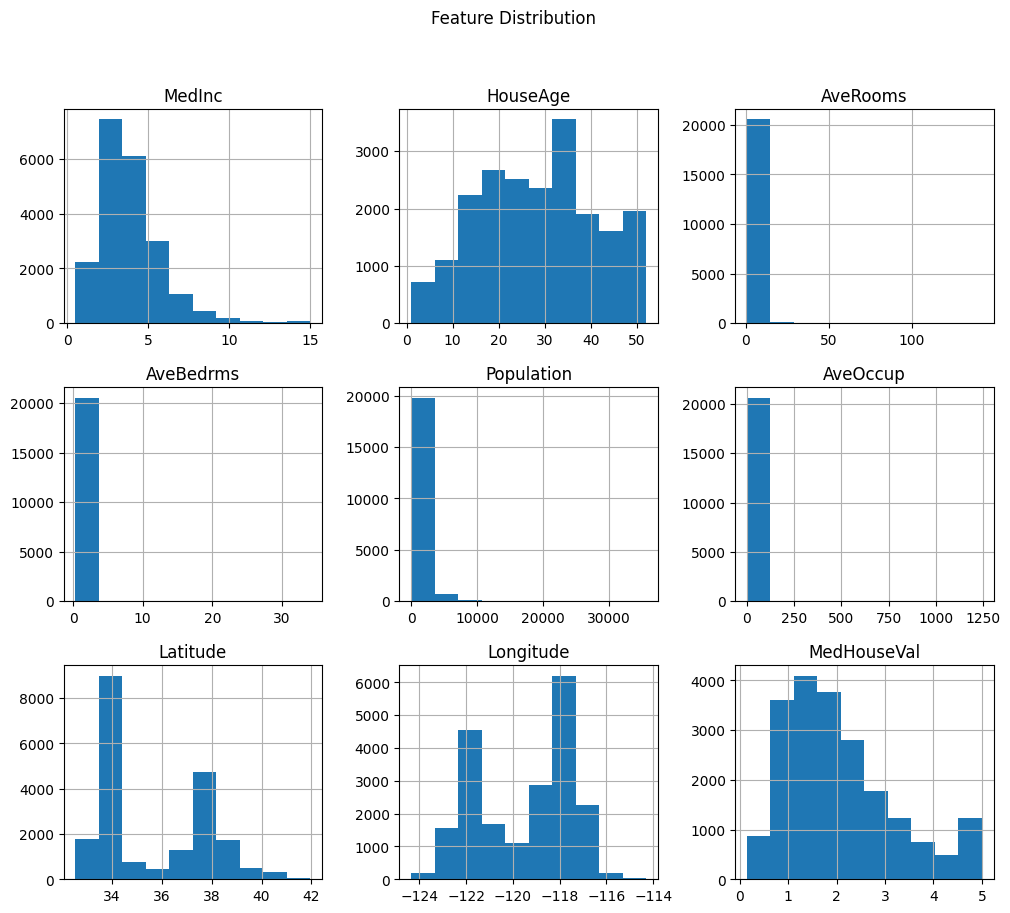

In [17]:
# Step 3: Exploratory Data Analysis (EDA)
# Histogram of all features
df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()


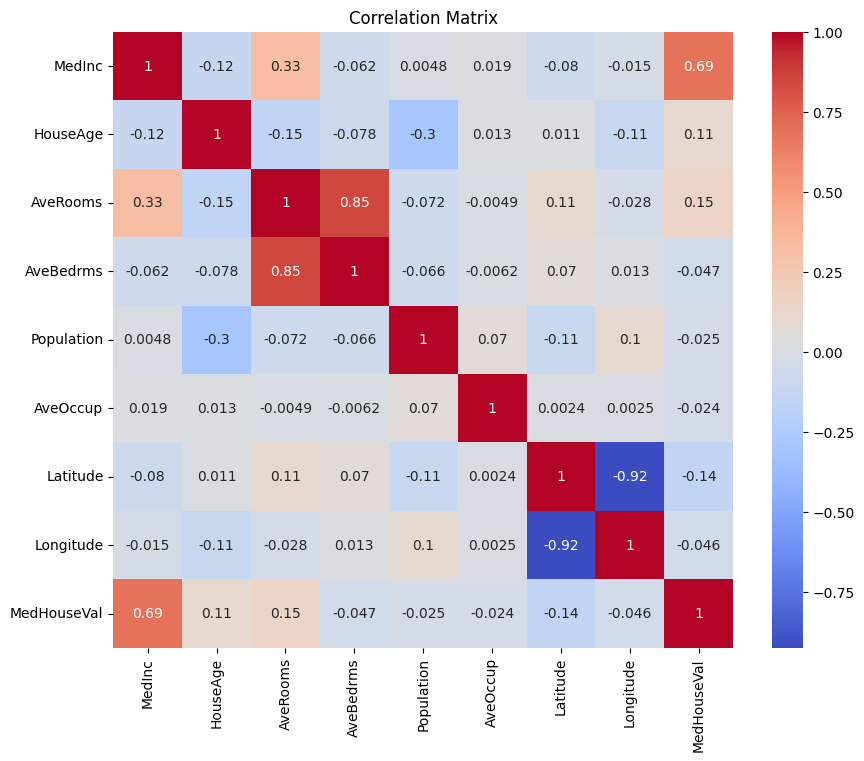

In [18]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

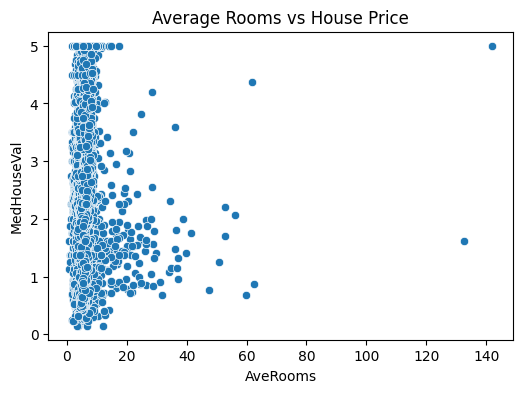

In [19]:
# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x="AveRooms", y="MedHouseVal", data=df)
plt.title("Average Rooms vs House Price")
plt.show()

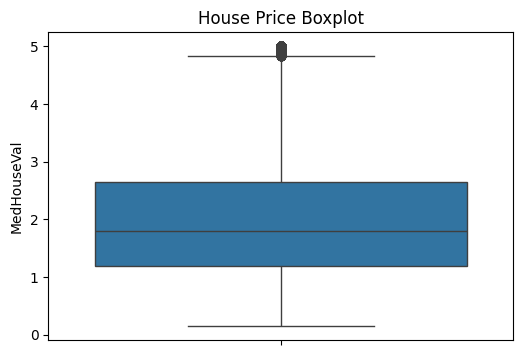

In [20]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=df["MedHouseVal"])
plt.title("House Price Boxplot")
plt.show()

In [21]:
# Step 4: Feature Engineering
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
print("\nFeatures Shape :", X.shape)
print("Target Shape :", y.shape)


Features Shape : (20640, 8)
Target Shape : (20640,)


In [22]:
# Step 5: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])


Training Samples : 16512
Testing Samples : 4128


In [23]:
# Step 6: Choose Model
model = LinearRegression()

# Step 7: Train Model
model.fit(X_train, y_train)
print("\nModel Trained Successfully")



Model Trained Successfully


In [24]:
# Step 8: Prediction
y_pred = model.predict(X_test)
print("\nFirst 10 Predictions")
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
print(comparison)


First 10 Predictions
    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615


In [25]:
# Step 9: Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\n========== Model Evaluation ==========")
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

# Cross Validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)
print("\nCross Validation Scores")
print(scores)
print("\nAverage CV Score :", scores.mean())

# Feature Importance (Regression Coefficients)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("\nRegression Coefficients")
print(coefficients)


========== Model Evaluation ==========
Mean Squared Error : 0.5558915986952444
Root Mean Squared Error : 0.7455813830127764
R2 Score : 0.5757877060324508

Cross Validation Scores
[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]

Average CV Score : 0.5530311140279569

Regression Coefficients
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


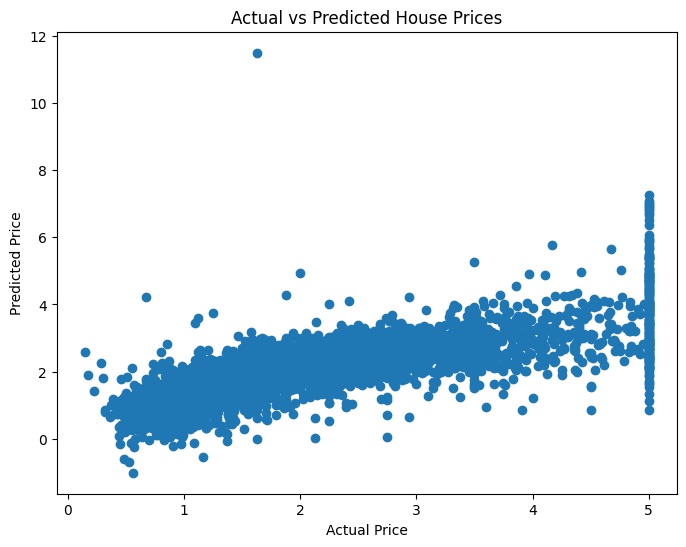

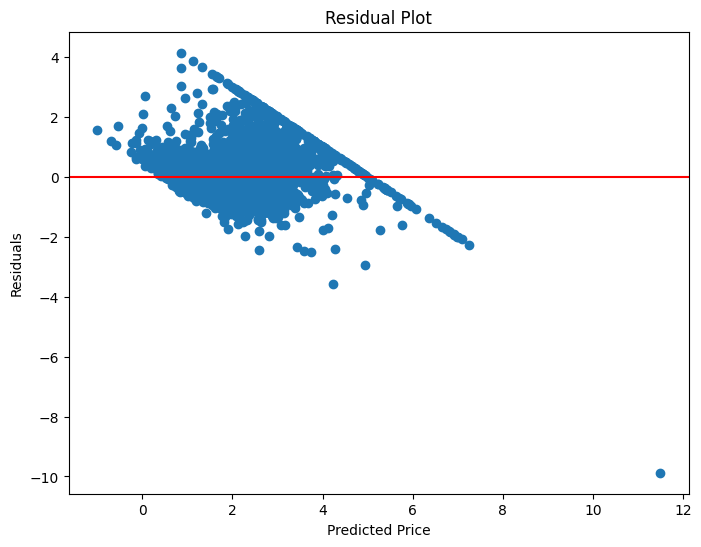

In [26]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [27]:
# Save Model
joblib.dump(model, "house_price_model.pkl")
print("\nModel Saved Successfully")


Model Saved Successfully


In [28]:
# Load Saved Model
loaded_model = joblib.load("house_price_model.pkl")
print("\nSaved Model Loaded Successfully")

# Predict New House
new_house = [[
    8.3252,   # MedInc
    41.0,     # HouseAge
    6.9841,   # AveRooms
    1.0238,   # AveBedrms
    322.0,    # Population
    2.5556,   # AveOccup
    37.88,    # Latitude
    -122.23   # Longitude
]]

prediction = loaded_model.predict(new_house)
print("Predicted House Price :", prediction[0])


Saved Model Loaded Successfully
Predicted House Price : 4.1519383982774585


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
